In [ ]:
!pip3 install torch torchvision

# Human Activity Recognition using CNN

This notebook shows how to train and evaluate a 1D convolutional neural network for the UCI HAR dataset.

>Anguita, D., Ghio, A., Oneto, L., Parra, X., & Reyes-Ortiz, J. L. (2013, April). A public domain dataset for human activity recognition using smartphones. In Esann (Vol. 3, No. 1, pp. 3-4).

This dataset contains data recorded from 30 volunteers performing six different activities, including 
1. Walking
2. Walking Upstairs
3. Walking Downstairs
4. Sitting
5. Standing
6. Laying

Participants wore a smartphone on their waist and data from the device's accelerometer and gyroscope was recorded. The data was collected at 50 samples/second, and then slip into segments of 2.58s resulting in a total of 128 samples per recording. 

For each activity, there are a total of 9 channels, including:
- total acceleration: x, y, z
- body acceleration: x, y, z
- body gyroscope: x, y, z

The *body acceleration* was derived from the *total acceleration* using a low pass filter.  

The dataset is split into training and test, there are a total of 7,352 records for training and 2,947 records for testing. There are many records per subject (hundreds), and data from a subject was used in the training or testing sets.

<div style="text-align:center">
<img src="images/SampleTask.png" alt="plot" width="800" />
</div>

WEBSITE: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones


In this notebook, we will create and train a CNN that receives as input the nine signals and outputs the probability of belong to a specific class.

## Learning goals
- understand the tensor shapes used for 1D CNNs
- load multichannel inertial signals from the UCI HAR dataset
- build a simple 1D CNN classifier
- train and evaluate the model
- compute a confusion matrix, ROC AUC, and per-class metrics


In this notebook, we will do five different steps:
1. load the data
2. inspect one sample
3. convert the data into PyTorch format
4. build a CNN
5. train and evaluate it

A lot of aspect of this notebook are related to PyTorch. We won't spend much time in these different components. Focus on the big picture rather than the implementations details.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

PYTORCH_ENABLE_MPS_FALLBACK=1 


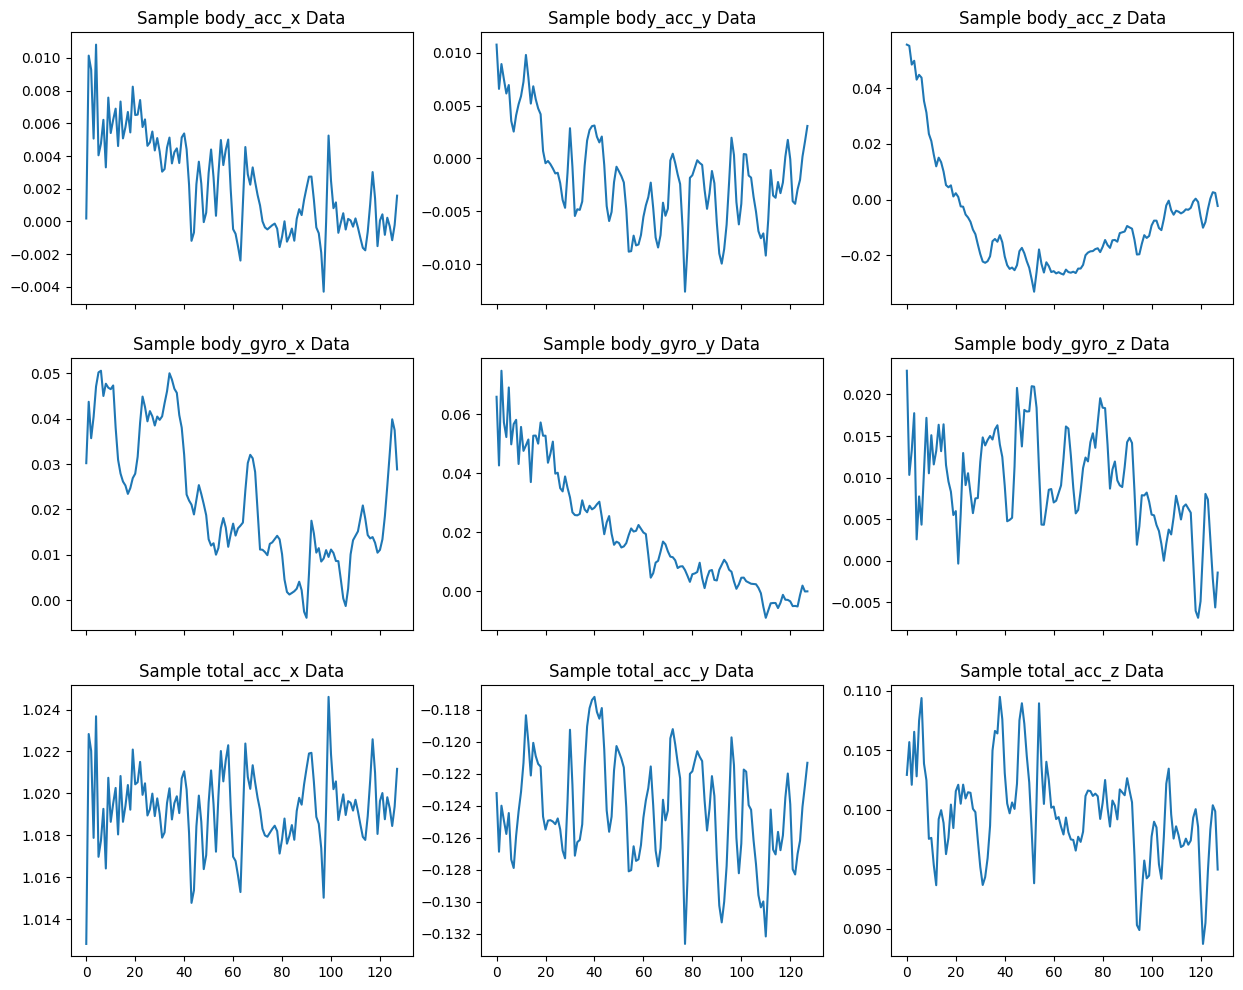

In [2]:
# load a sample data and visualize it, the dataset contains
# body_acc_x, body_acc_y, body_acc_z, 
# body_gyro_x, body_gyro_y, body_gyro_z, 
# total_acc_x, total_acc_y, total_acc_z for each sample
data_path = Path('data/UCI_HAR_Dataset')

fig, ax = plt.subplots(3, 3, figsize=(15, 12), sharex = True)
signal_names = ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']
for i, signal in enumerate(signal_names):
    sample_file = data_path / 'train' / 'Inertial Signals' / f'{signal}_train.txt'
    sample_data = np.loadtxt(sample_file)
    ax[i // 3, i % 3].plot(sample_data[0])
    ax[i // 3, i % 3].set_title(f'Sample {signal} Data')

plt.show()

The goal is then to create a CNN that will take these 9 signals, process them using kernels, non-linearities, and down-sampling steps, to then generate a feature vector that is passed to a fully connected network, which will then predict the probability of each class. 

We need to send data to the model. However, there is too much data, and sending it all together would be computational inefficient and memory intensive.  

Instead, we send data in small groups, called batches. During training, the batch of data is used to compute gradients and update the model parameters. This process is then repeated the with a new batch of data. 

The batch of data is chosen randomly from the full dataset.

For this, you need to tell the model where the data is and how to load it. In PyTorch this is known as a **DATASET**. The model will call this dataset when data is needed  

In [103]:
#this function reads the data from the text files and returns it as a numpy array that can be send to the model. 
def load_file(filepath):
    return pd.read_csv(filepath, header=None, sep=r'\s+').values

#this function organizes the filenames for the different signals so they can be loaded 
def load_group(filenames, prefix):
    loaded = [load_file(prefix / name) for name in filenames]
    return np.dstack(loaded)

#this function loads the dataset for a given group (train or test) and returns the signals and labels as numpy arrays.
def load_dataset_group(group, path):
    filepath = path / group / 'Inertial Signals'
    filenames = [
        f'total_acc_x_{group}.txt', f'total_acc_y_{group}.txt', f'total_acc_z_{group}.txt',
        f'body_acc_x_{group}.txt', f'body_acc_y_{group}.txt', f'body_acc_z_{group}.txt',
        f'body_gyro_x_{group}.txt', f'body_gyro_y_{group}.txt', f'body_gyro_z_{group}.txt',
    ]
    X = load_group(filenames, filepath)
    y = load_file(path / group / f'y_{group}.txt').squeeze().astype(int) - 1
    return X, y


basePath = Path('data/UCI_HAR_Dataset')
trainX, trainy = load_dataset_group('train', basePath)
testX, testy = load_dataset_group('test', basePath)

print(trainX.shape, trainy.shape, testX.shape, testy.shape)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
(7352, 128, 9) (7352,) (2947, 128, 9) (2947,)


Note that the training set dimensions are 
- `(7352, 128, 9)`

This means that there are 7352 samples, and each sample has signals of length 128, and there are 9 signals per sample. 



Class: Walking Downstairs (2)


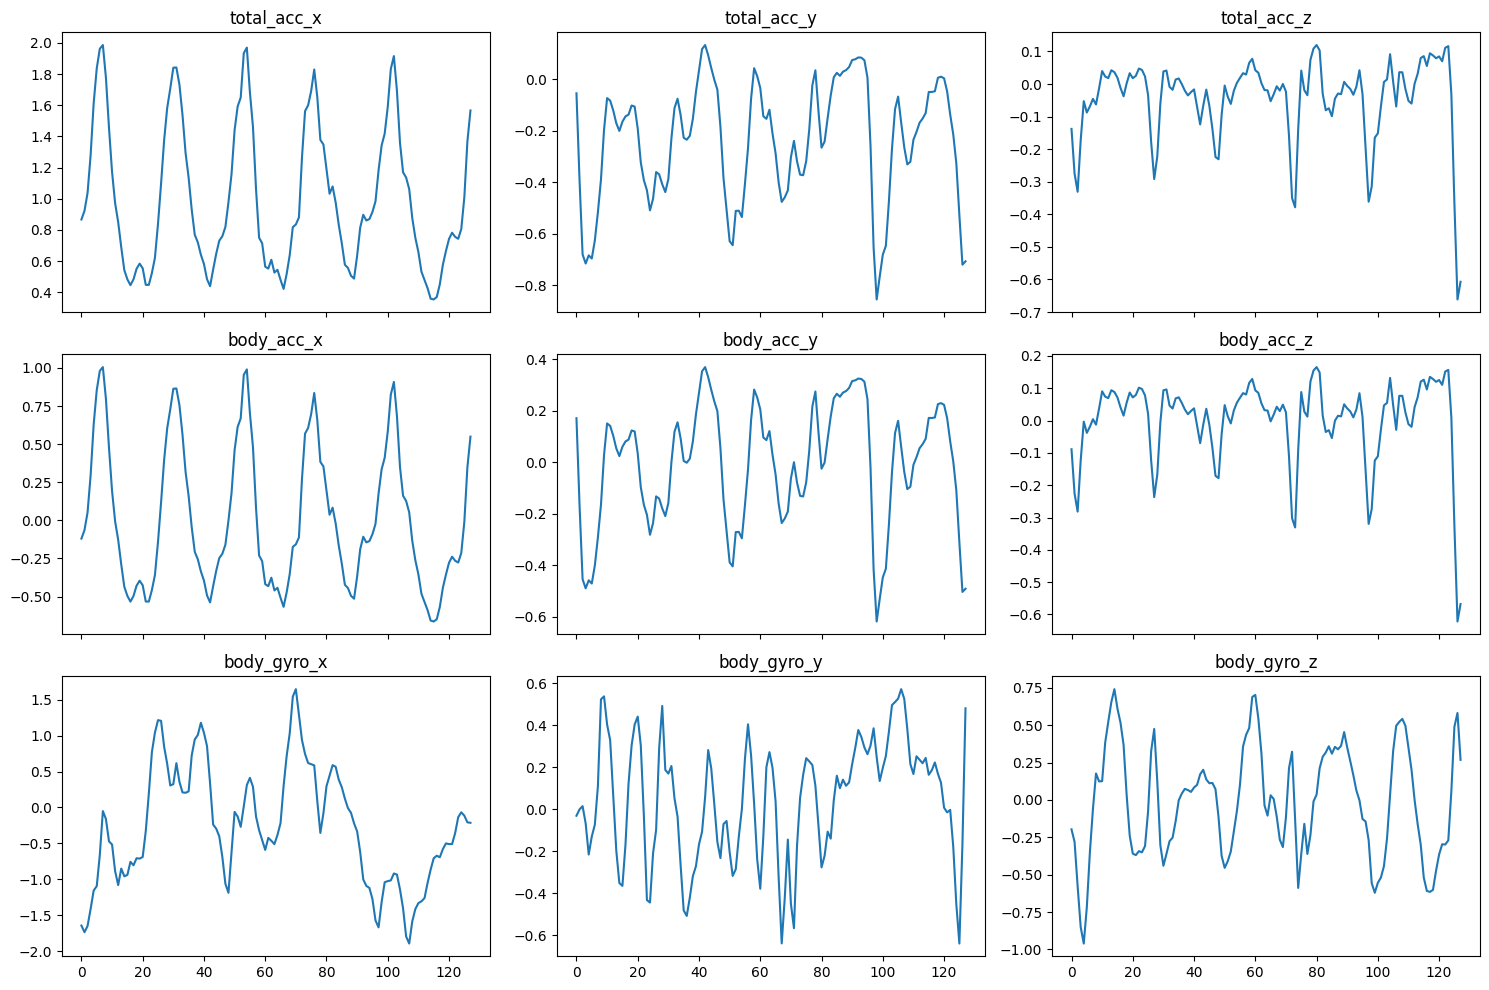

In [4]:
idx = 4658
sample_signal = trainX[idx]
sample_label = trainy[idx]

class_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
channel_names = [
    'total_acc_x', 'total_acc_y', 'total_acc_z',
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z'
]

print(f'Class: {class_names[sample_label]} ({sample_label})')

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
for j, name in enumerate(channel_names):
    axes[j // 3, j % 3].plot(sample_signal[:, j])
    axes[j // 3, j % 3].set_title(name)

plt.tight_layout()
plt.show()


In [5]:
#create a DATASET class to load the data and return it as a tensor that can be send to the model.

class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = HARDataset(trainX, trainy)
test_dataset = HARDataset(testX, testy)

xb, yb = train_dataset[0]
print('Single sample shape:', xb.shape)
print('Single label:', yb)

Single sample shape: torch.Size([9, 128])
Single label: tensor(4)


In [21]:
#create a small CNN model to classify the data, the model should have 3 convolutional layers and 2 fully connected layers. 
# The model should receive the 9 channels of data and be able to classify the data into 6 classes.
class CNN1D(nn.Module):
    def __init__(self, n_features=9, n_outputs=6, n_timesteps=128):
        super().__init__()
        self.features = nn.Sequential(
            #block 1
            nn.Conv1d(in_channels=n_features, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool1d(kernel_size=2),
            
            #block 2
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.MaxPool1d(kernel_size=2),
        )

        with torch.no_grad():
            flat_dim = self.features(torch.zeros(1, n_features, n_timesteps)).reshape(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 100),
            nn.ReLU(),
            nn.Linear(100, n_outputs),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN1D()
print(model)

CNN1D(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,))
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1920, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=6, bias=True)
  )
)


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model = CNN1D().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# try:
#     model = torch.compile(model)
#     print('Model compiled with torch.compile()')
# except Exception:
#     print('torch.compile() not available in this environment; continuing without compilation')

In [23]:
#helper function to train the model for one epoch and return the average loss and accuracy for that epoch.
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(yb)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += len(yb)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    y_true, y_pred, y_prob = [], [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.softmax(logits, dim=1)

        running_loss += loss.item() * len(yb)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += len(yb)

        y_true.append(yb.cpu().numpy())
        y_pred.append(logits.argmax(dim=1).cpu().numpy())
        y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    return running_loss / total, correct / total, y_true, y_pred, y_prob



In [24]:
epochs = 20
history = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, y_true, y_pred, y_prob = evaluate_model(model, test_loader, criterion, device)

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc
    })

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch 01/20 | Train Loss: 0.7479 | Train Acc: 0.6942 | Test Loss: 0.6617 | Test Acc: 0.7757
Epoch 02/20 | Train Loss: 0.3121 | Train Acc: 0.8837 | Test Loss: 0.5023 | Test Acc: 0.8422
Epoch 03/20 | Train Loss: 0.2010 | Train Acc: 0.9236 | Test Loss: 0.4080 | Test Acc: 0.8918
Epoch 04/20 | Train Loss: 0.1567 | Train Acc: 0.9374 | Test Loss: 0.3591 | Test Acc: 0.9002
Epoch 05/20 | Train Loss: 0.1325 | Train Acc: 0.9445 | Test Loss: 0.3437 | Test Acc: 0.9138
Epoch 06/20 | Train Loss: 0.1342 | Train Acc: 0.9434 | Test Loss: 0.3363 | Test Acc: 0.9060
Epoch 07/20 | Train Loss: 0.1297 | Train Acc: 0.9455 | Test Loss: 0.3077 | Test Acc: 0.9023
Epoch 08/20 | Train Loss: 0.1188 | Train Acc: 0.9487 | Test Loss: 0.3074 | Test Acc: 0.9019
Epoch 09/20 | Train Loss: 0.1169 | Train Acc: 0.9493 | Test Loss: 0.2910 | Test Acc: 0.9158
Epoch 10/20 | Train Loss: 0.1118 | Train Acc: 0.9510 | Test Loss: 0.2796 | Test Acc: 0.9138
Epoch 11/20 | Train Loss: 0.1065 | Train Acc: 0.9524 | Test Loss: 0.2706 | Test 

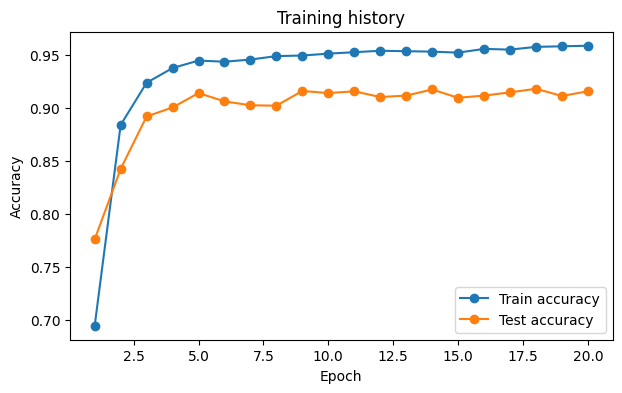

In [25]:
history_df = pd.DataFrame(history)
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_acc'], marker='o', label='Train accuracy')
plt.plot(history_df['epoch'], history_df['test_acc'], marker='o', label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training history')
plt.legend()
plt.show()

In [14]:
class_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

,Walking,Walking Upstairs,Walking Downstairs,Sitting,Standing,Laying
Walking,461,9,26,0,0,0
Walking Upstairs,3,441,27,0,0,0
Walking Downstairs,5,11,404,0,0,0
Sitting,0,25,0,407,59,0
Standing,1,3,0,77,451,0
Laying,0,27,0,0,0,510


How to interpret the confusion matrix:
- diagonal elements = correct predictions
- off-diagonal elements = mistakes


In [15]:
report_df = pd.DataFrame(classification_report(y_true, y_pred, target_names=class_names, output_dict=True)).T
report_df

,precision,recall,f1-score,support
Walking,0.980851,0.929435,0.954451,496.000000
Walking Upstairs,0.854651,0.936306,0.893617,471.000000
Walking Downstairs,0.884026,0.961905,0.921323,420.000000
Sitting,0.840909,0.828921,0.834872,491.000000
Standing,0.884314,0.847744,0.865643,532.000000
Laying,1.000000,0.949721,0.974212,537.000000
accuracy,0.907363,0.907363,0.907363,0.907363
macro avg,0.907459,0.909005,0.907353,2947.000000
weighted avg,0.909628,0.907363,0.907653,2947.000000


In [108]:
# Build the model using the data dimensions
n_features = trainX.shape[2]      # 9 channels
n_timesteps = trainX.shape[1]     # 128 samples
n_outputs = len(np.unique(trainy))  # number of classes

model = CNN1D()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 199,810
Trainable parameters: 199,810
